In [10]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Parámetros
productos = ['Cemento', 'Arena', 'Lastre', 'Grava', 'Granito', 'Marmol',"Porcelanato","Ceramica"]
categorias = {'Cemento': 'Material de construccion', 'Arena': 'Material de construccion', 'Lastre': 'Material de construccion',
              'Grava': 'Material de construccion', 'Granito': 'Acabados', 'Marmol': 'Acabados', 'Porcelanato': 'Acabados', 'Ceramica': 'Acabados'}
regiones = ['Norte', 'Sur', 'Este', 'Oeste']
clientes = ['Carlos', 'María', 'José', 'Ana', 'Luis', 'Carmen', 'Jorge', 'Lucía',
            'Pedro', 'Laura', 'Andrés', 'Marta', 'Diego', 'Sofía', 'Fernando', 'Elena',
            'Miguel', 'Patricia', 'Ricardo', 'Isabel']

# Generar datos
np.random.seed(42)
fechas = [datetime(2023, 1, 1) + timedelta(days=random.randint(0, 364)) for _ in range(500)]
productos_sample = [random.choice(productos) for _ in range(500)]
categorias_sample = [categorias[p] for p in productos_sample]
regiones_sample = [random.choice(regiones) for _ in range(500)]
clientes_sample = [random.choice(clientes) for _ in range(500)]
cantidades = np.random.randint(1, 10, size=500)
precios_unitarios = [random.randint(5, 50) for _ in range(500)]
total_venta = [c * p for c, p in zip(cantidades, precios_unitarios)]

# Crear DataFrame
df = pd.DataFrame({
    'Fecha': fechas,
    'Producto': productos_sample,
    'Categoría': categorias_sample,
    'Región': regiones_sample,
    'Cliente': clientes_sample,
    'Cantidad': cantidades,
    'Precio Unitario': precios_unitarios,
    'Total Venta': total_venta
})

print(df.head())


       Fecha     Producto                 Categoría Región   Cliente  \
0 2023-07-17       Lastre  Material de construccion  Norte    Carmen   
1 2023-06-20        Arena  Material de construccion  Oeste       Ana   
2 2023-09-26  Porcelanato                  Acabados  Oeste     Marta   
3 2023-02-19        Grava  Material de construccion    Sur  Patricia   
4 2023-05-29        Grava  Material de construccion  Norte    Carlos   

   Cantidad  Precio Unitario  Total Venta  
0         7               26          182  
1         4               31          124  
2         8               41          328  
3         5               21          105  
4         7               44          308  


In [11]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            500 non-null    datetime64[ns]
 1   Producto         500 non-null    object        
 2   Categoría        500 non-null    object        
 3   Región           500 non-null    object        
 4   Cliente          500 non-null    object        
 5   Cantidad         500 non-null    int32         
 6   Precio Unitario  500 non-null    int64         
 7   Total Venta      500 non-null    int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(4)
memory usage: 27.5+ KB


Fecha              0
Producto           0
Categoría          0
Región             0
Cliente            0
Cantidad           0
Precio Unitario    0
Total Venta        0
dtype: int64

In [12]:
# 1. Ventas por región
print(df['Región'].value_counts())

# 2. Ingreso total por categoría
print(df.groupby('Categoría')['Total Venta'].sum())

# 3. Cliente con más compras
print(df['Cliente'].value_counts().head(1))


Región
Este     146
Sur      125
Norte    122
Oeste    107
Name: count, dtype: int64
Categoría
Acabados                    31562
Material de construccion    36608
Name: Total Venta, dtype: int32
Cliente
Jorge    42
Name: count, dtype: int64


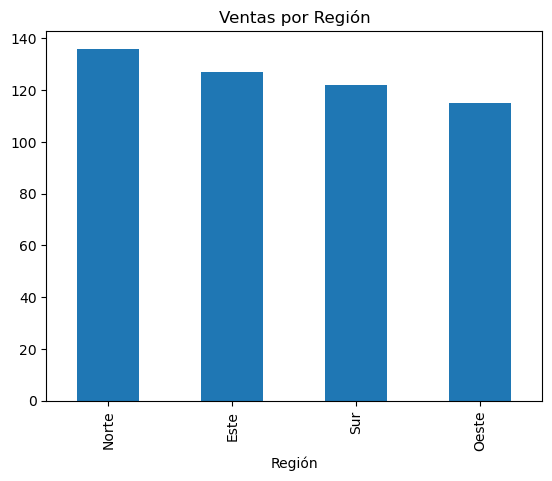

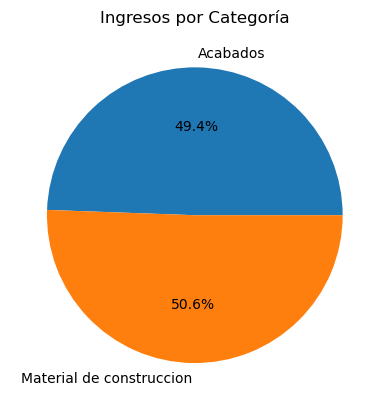

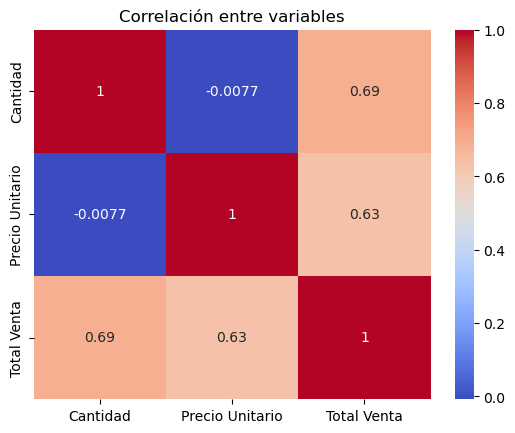

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ventas por región
df['Región'].value_counts().plot(kind='bar', title='Ventas por Región')
plt.show()

# Ingreso por categoría
df.groupby('Categoría')['Total Venta'].sum().plot(kind='pie', autopct='%1.1f%%', title='Ingresos por Categoría')
plt.ylabel('')
plt.show()

# Mapa de calor de correlación
sns.heatmap(df[['Cantidad', 'Precio Unitario', 'Total Venta']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables')
plt.show()
